11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images : (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.8727 - loss: 0.4773 - val_accuracy: 0.9763 - val_loss: 0.0808
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9784 - loss: 0.0726 - val_accuracy: 0.9862 - val_loss: 0.0546
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9870 - loss: 0.0468 - val_accuracy: 0.9877 - val_loss: 0.0492
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.9903 - loss: 0.0327 - val_accuracy: 0.9877 - val_loss: 0.0454
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.9930 - loss: 0.0239 - val_accuracy: 0.9875 - val_loss: 0.0486
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9814 - loss: 0.0569
Test Accuracy: 0.9850999712944031


Saving 2.webp to 2.webp


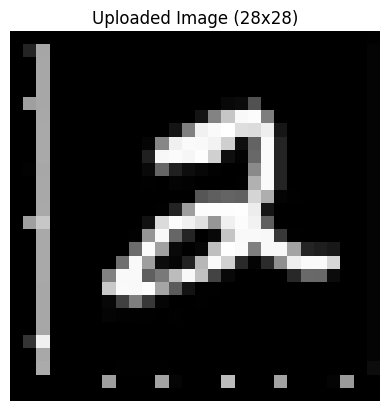

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted Digit: 2


In [ ]:
#Introduction to Dl for Image classification

import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from google.colab import files

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Testinag images :", X_test.shape)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

X_train = X_train / 255.0
X_test  = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

uploaded = files.upload()

for file_name in uploaded.keys():
    img = cv2.imread(file_name)

if len(img.shape) == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img

img_resized = cv2.resize(img_gray, (28, 28))

img_resized = 255 - img_resized

img_resized = img_resized / 255.0

img_input = img_resized.reshape(1, 28, 28, 1)

plt.imshow(img_resized, cmap='gray')
plt.title("Uploaded Image (28x28)")
plt.axis('off')
plt.show()

prediction = model.predict(img_input)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)
